In [1]:
import os
import json
import pickle
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric.transforms as T
from torch_geometric.loader import DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torch_geometric.nn.attention import PerformerAttention
from torch_geometric.nn.attention.performer import generalized_kernel
from torch_geometric.nn import GATv2Conv
from shapely.geometry import Point, LineString, Polygon
import h3pandas
import numpy as np
import pandas as pd
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
from collections import Counter
import torch_geometric
from torch_geometric.data import Data
from shapely import wkt
import contextily as cx
import h3pandas
import seaborn as sns
from utils import *
from models import *

# Preprocessing

In [2]:
#load paris geoJson edge and nodes
paris_edges = gpd.read_file('data/paris_edges.geojson')
paris_nodes = gpd.read_file('data/paris_nodes.geojson')

h3_edges = gpd.read_file('data/h3_edges.geojson')
h3_nodes = gpd.read_file('data/h3_nodes.geojson')
h3_nodes.index = h3_nodes['h3_09'] 
h3_nodes.drop(columns=['h3_09'], inplace=True)

Skipping field osmid: unsupported OGR type: 13


In [58]:
amsterdam_edges = gpd.read_file('data/amsterdam_edges.geojson')
amsterdam_nodes = gpd.read_file('data/amsterdam_nodes.geojson')

In [59]:
amsterdam_nodes.drop(columns=['node_id','Green View Stdev','Sky View Stdev','Building View Stdev','Road View Stdev', 'Visual Complexity Mean','Visual Complexity Stdev'  ], inplace=True)
print(amsterdam_nodes.columns)
amsterdam_nodes.fillna(0, inplace=True)

Index(['osmid', 'x', 'y', 'Node Density', 'Street Length', 'Degree',
       'Clustering', 'Clustering (Weighted)', 'Closeness Centrality',
       'Betweenness Centrality', 'Eigenvector Centrality', 'Katz Centrality',
       'PageRank', 'Footprint Proportion', 'Footprint Mean', 'Footprint Stdev',
       'Perimeter Total', 'Perimeter Mean', 'Perimeter Stdev',
       'Complexity Mean', 'Complexity Stdev', 'Building Count', 'PopSum',
       'Men', 'Women', 'Elderly', 'Youth', 'Children', 'Civic', 'Commercial',
       'Entertainment', 'Food', 'Healthcare', 'Institutional', 'Recreational',
       'Social', 'Green View Mean', 'Sky View Mean', 'Building View Mean',
       'Road View Mean', 'geometry'],
      dtype='object')


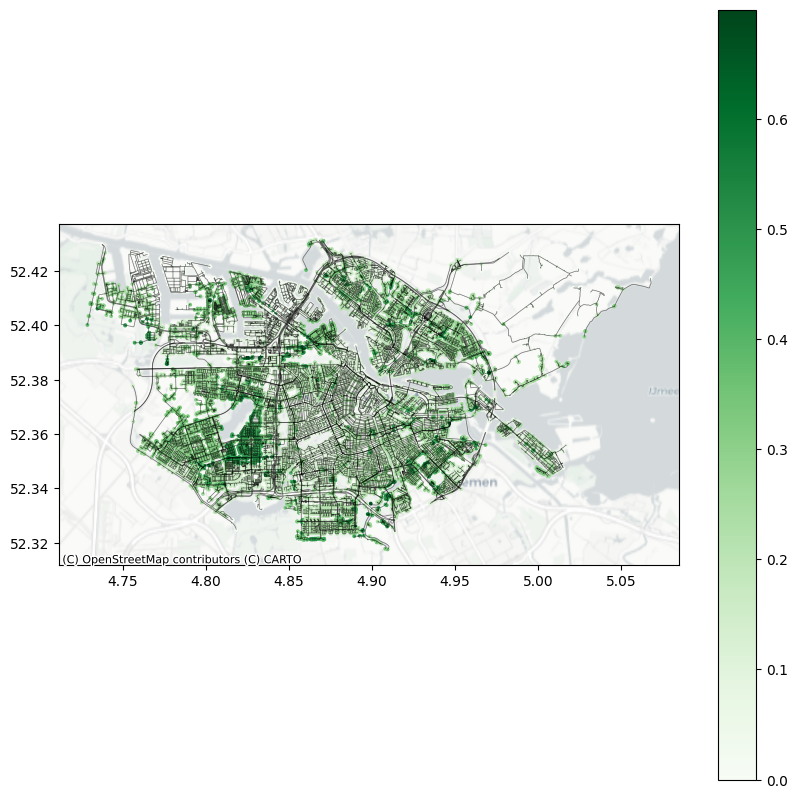

In [5]:
f, ax = plt.subplots(figsize=(10, 10))
amsterdam_edges.plot(ax=ax, color='black', linewidth=0.5, alpha=0.3)
amsterdam_nodes.plot(ax=ax, column= 'Green View Mean', cmap= 'Greens', legend=True, markersize=3)
cx.add_basemap(ax, crs=amsterdam_nodes.crs.to_string(), source=cx.providers.CartoDB.Positron)

In [60]:
agg_amst = {
    # ─── identifiers & coordinates ───────────────────────────────
    "osmid"                    : lambda s: list(s),   
    "x"                        : "mean",              
    "y"                        : "mean",
    

    # ─── street-network structure ────────────────────────────────
    "Node Density"             : "mean",              
    "Street Length"            : "mean",
    "Degree"                   : "mean",
    "Clustering"               : "mean",
    "Clustering (Weighted)"    : "mean",
    "Closeness Centrality"     : "mean",
    "Betweenness Centrality"   : "mean",
    "Eigenvector Centrality"   : "mean",
    "Katz Centrality"          : "mean",
    "PageRank"                 : "mean",
    
    # ─── building-footprint morphology ───────────────────────────
    "Footprint Proportion"     : "mean",             
    "Footprint Mean"           : "mean",
    "Footprint Stdev"          : "mean",
    "Perimeter Total"          : "mean",
    "Perimeter Mean"           : "mean",
    "Perimeter Stdev"          : "mean",
    "Complexity Mean"          : "mean",
    "Complexity Stdev"         : "mean",
    "Building Count"           : "mean",
    
    # ─── demography ──────────────────────────────────────────────
    "PopSum"                   : "sum",
    "Men"                      : "sum",
    "Women"                    : "sum",
    "Elderly"                  : "sum",
    "Youth"                    : "sum",
    "Children"                 : "sum",
    
    # ─── POI land-use counts ─────────────────────────────────────
    "Civic"                    : "sum",
    "Commercial"               : "sum",
    "Entertainment"            : "sum",
    "Food"                     : "sum",
    "Healthcare"               : "sum",
    "Institutional"            : "sum",
    "Recreational"             : "sum",
    "Social"                   : "sum",
    
    # ─── street-level vision indices ─────────────────────────────
    "Green View Mean"               : "mean",
    "Sky View Mean"                 : "mean",
    "Building View Mean"            : "mean",
    "Road View Mean"                : "mean",
}

/Users/stefanocarotti/FBK/GDS/Urbanity/utils.py:607: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  h3_nodes_amst['x'] = h3_nodes_amst.geometry.centroid.x
/Users/stefanocarotti/FBK/GDS/Urbanity/utils.py:608: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  h3_nodes_amst['y'] = h3_nodes_amst.geometry.centroid.y


<Axes: >

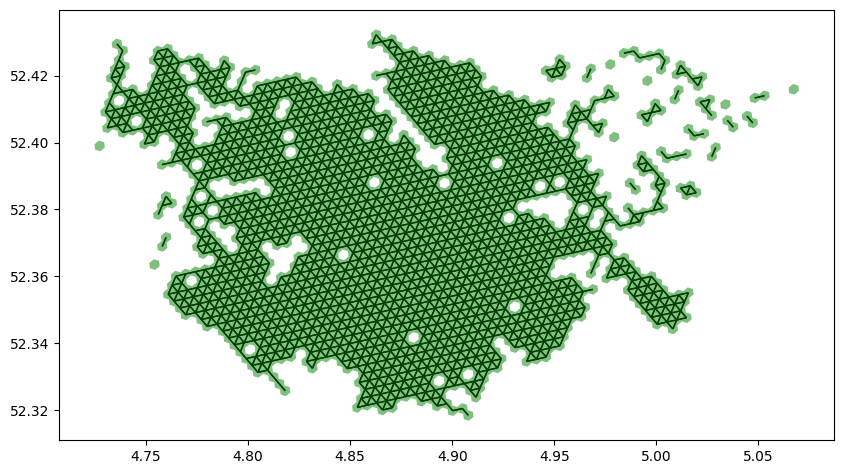

In [6]:
h3_nodes_amst, h3_edges_amst = create_h3_aggregated_graph( amsterdam_nodes, agg_amst, h3_resolution=9)
f, ax = plt.subplots(1, 1, figsize=(10, 10))
h3_edges_amst.plot(ax=ax, color='black', linewidth=1, zorder=1)
h3_nodes_amst.plot(ax=ax, color='green', markersize=1, zorder=2, alpha=0.5)

In [ ]:
#save nodes and edges to geojson
h3_nodes_amst.fillna(0, inplace=True)
h3_edges_amst.to_file('data/h3_edges_amst.geojson', driver='GeoJSON')
h3_nodes_amst.to_file('data/h3_nodes_amst.geojson', driver='GeoJSON')


Skipping field osmid: unsupported OGR type: 13


In [3]:
#load the h3 edges and nodes
h3_edges_amst = gpd.read_file('data/h3_edges_amst.geojson')
h3_nodes_amst = gpd.read_file('data/h3_nodes_amst.geojson')
h3_nodes_amst.index = h3_nodes_amst['h3_09']
h3_nodes_amst.drop(columns=['h3_09'], inplace=True)

Skipping field osmid: unsupported OGR type: 13


In [8]:
#create POI variable: 
poi_cols = ['Civic', 'Commercial','Entertainment', 'Food', 'Healthcare', 'Institutional', 'Recreational', 'Social']
h3_nodes_amst["POI"] = h3_nodes[poi_cols].sum(axis=1)
h3_nodes_amst.fillna(0, inplace=True)

In [ ]:
device = 'cpu'
BasicData = preprocess_data(h3_nodes_amst, h3_edges_amst, X_list= ['x', 'y','PopSum', 'POI' ,'Sky View Mean'], target='Green View Mean')
BasicData = BasicData.to(device)
print(BasicData)

Data(x=[1614, 5], edge_index=[2, 8300], y=[1614], pe=[1614, 20], train_mask=[1614], val_mask=[1614], test_mask=[1614])


In [9]:
milan_edges = gpd.read_file('data/milan_edges.geojson')
milan_nodes = gpd.read_file('data/milan_nodes.geojson')

In [10]:
milan_nodes.drop(columns=['node_id','Green View Stdev','Sky View Stdev','Building View Stdev','Road View Stdev', 'Visual Complexity Mean','Visual Complexity Stdev'  ], inplace=True)
milan_nodes.fillna(0, inplace=True)

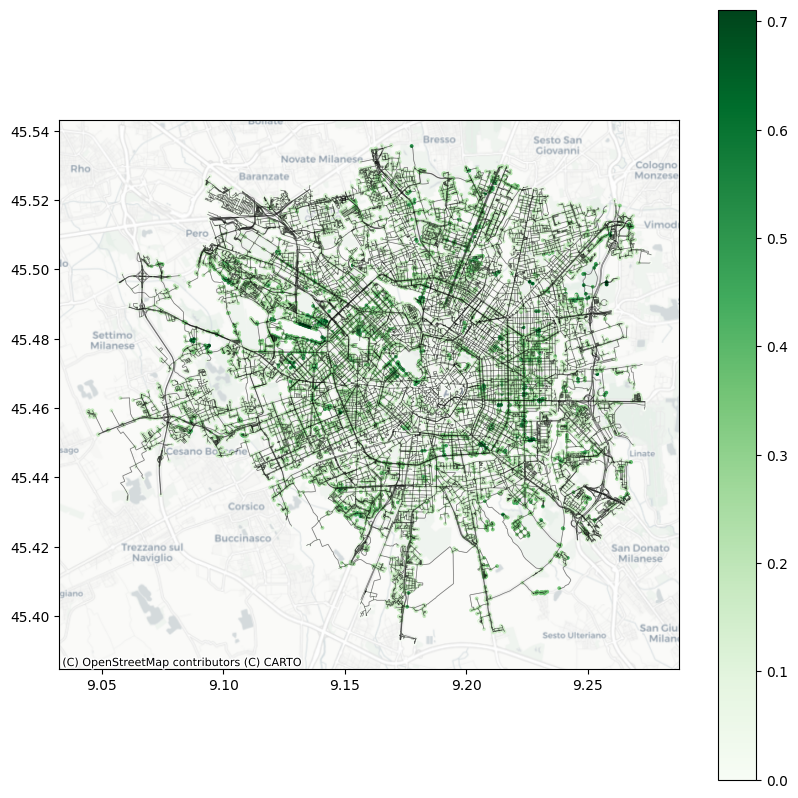

In [11]:
f, ax = plt.subplots(figsize=(10, 10))
milan_edges.plot(ax=ax, color='black', linewidth=0.5, alpha=0.3)
milan_nodes.plot(ax=ax, column= 'Green View Mean', cmap= 'Greens', legend=True, markersize=3)
cx.add_basemap(ax, crs=milan_nodes.crs.to_string(), source=cx.providers.CartoDB.Positron)

/Users/stefanocarotti/FBK/GDS/Urbanity/utils.py:607: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  h3_nodes_amst['x'] = h3_nodes_amst.geometry.centroid.x
/Users/stefanocarotti/FBK/GDS/Urbanity/utils.py:608: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  h3_nodes_amst['y'] = h3_nodes_amst.geometry.centroid.y


<Axes: >

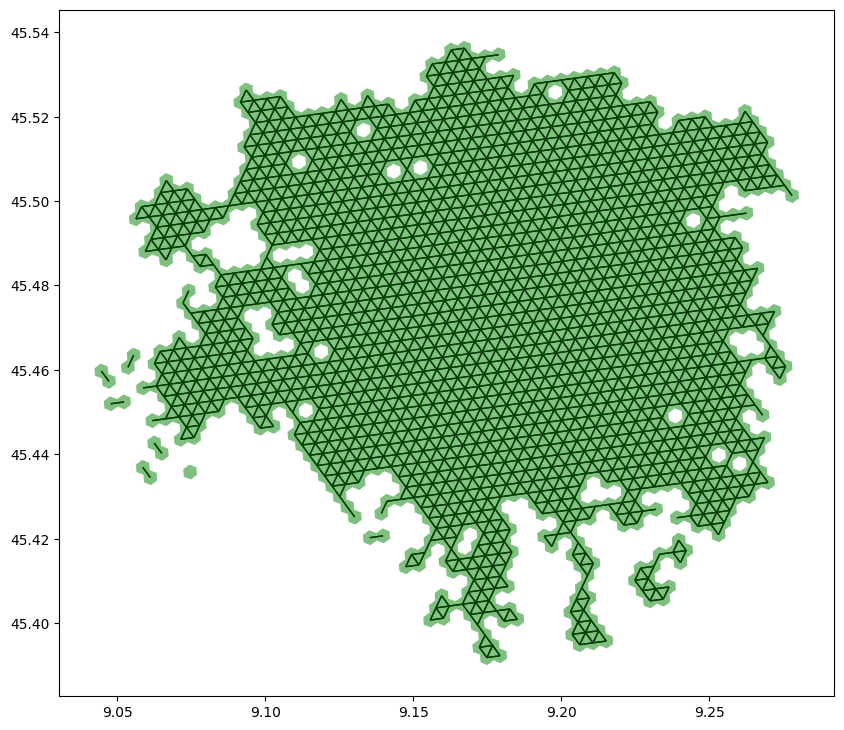

In [14]:
h3_nodes_milan, h3_edges_milan = create_h3_aggregated_graph(milan_nodes, agg_amst, h3_resolution=9)
f, ax = plt.subplots(1, 1, figsize=(10, 10))
h3_edges_milan.plot(ax=ax, color='black', linewidth=1, zorder=1)
h3_nodes_milan.plot(ax=ax, color='green', markersize=1, zorder=2, alpha=0.5)

In [4]:
#save nodes and edges to geojson
h3_nodes_milan.fillna(0, inplace=True)
h3_edges_milan.to_file('data/h3_edges_milan.geojson', driver='GeoJSON')
h3_nodes_milan.to_file('data/h3_nodes_milan.geojson', driver='GeoJSON')


NameError: name 'h3_nodes_milan' is not defined

In [4]:
#load the h3 edges and nodes
h3_edges_milan = gpd.read_file('data/h3_edges_milan.geojson')
h3_nodes_milan = gpd.read_file('data/h3_nodes_milan.geojson')
h3_nodes_milan.index = h3_nodes_milan['h3_09']
h3_nodes_milan.drop(columns=['h3_09'], inplace=True)

Skipping field osmid: unsupported OGR type: 13


In [63]:
h3_nodes_milan['Green View'] = h3_nodes_milan['Green View Mean']

In [14]:
barcelona_edges = gpd.read_file('data/barcelona_edges.geojson')
barcelona_nodes = gpd.read_file('data/barcelona_nodes.geojson')
barcelona_nodes.drop(columns=['node_id','Green View Stdev','Sky View Stdev','Building View Stdev','Road View Stdev', 'Visual Complexity Mean','Visual Complexity Stdev'  ], inplace=True)
barcelona_nodes.fillna(0, inplace=True)

/Users/stefanocarotti/FBK/GDS/Urbanity/utils.py:607: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  h3_nodes_amst['x'] = h3_nodes_amst.geometry.centroid.x
/Users/stefanocarotti/FBK/GDS/Urbanity/utils.py:608: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  h3_nodes_amst['y'] = h3_nodes_amst.geometry.centroid.y
Skipping field osmid: unsupported OGR type: 13


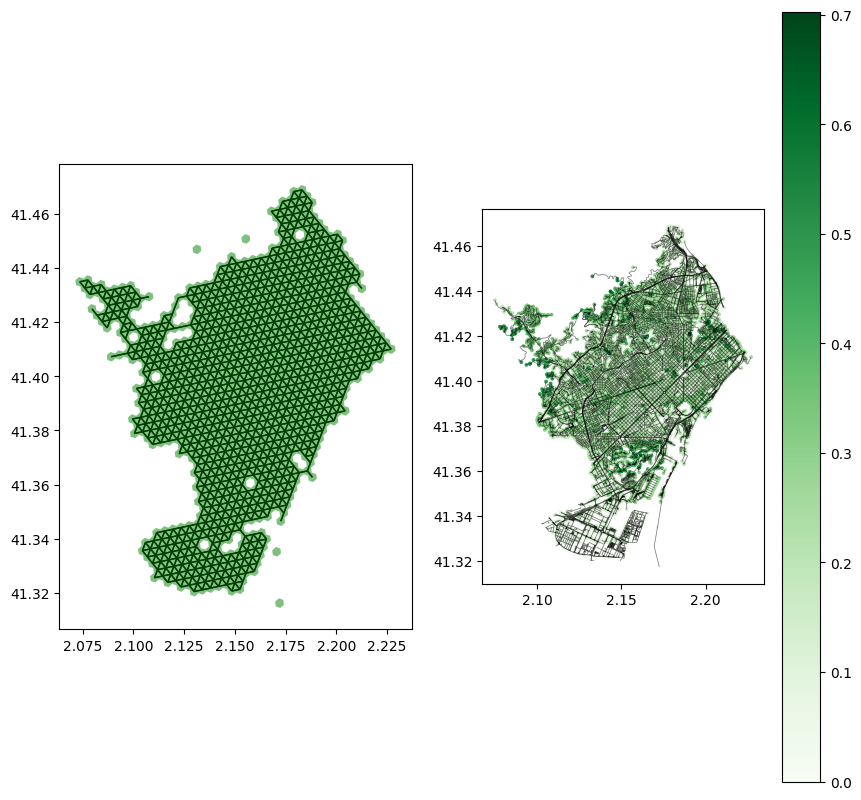

In [ ]:
h3_nodes_barcelona, h3_edges_barcelona = create_h3_aggregated_graph(barcelona_nodes, agg_amst, h3_resolution=9)
f, ax = plt.subplots(1, 2, figsize=(10, 10))
h3_edges_barcelona.plot(ax=ax[0], color='black', linewidth=1, zorder=1)
h3_nodes_barcelona.plot(ax=ax[0], color='green', markersize=1, zorder=2, alpha=0.5)
barcelona_nodes.plot(ax=ax[1], column='Green View Mean', cmap='Greens', legend=True, markersize=3)
barcelona_edges.plot(ax=ax[1], color='black', linewidth=0.5, alpha=0.3)

#save nodes and edges to geojson
h3_nodes_barcelona.fillna(0, inplace=True)
h3_edges_barcelona.to_file('data/h3_edges_barcelona.geojson', driver='GeoJSON')
h3_nodes_barcelona.to_file('data/h3_nodes_barcelona.geojson', driver='GeoJSON')


In [5]:
#load the h3 edges and nodes
h3_edges_barcelona = gpd.read_file('data/h3_edges_barcelona.geojson')
h3_nodes_barcelona = gpd.read_file('data/h3_nodes_barcelona.geojson')
h3_nodes_barcelona.index = h3_nodes_barcelona['h3_09']
h3_nodes_barcelona.drop(columns=['h3_09'], inplace=True)
h3_nodes_barcelona['Green View'] = h3_nodes_barcelona['Green View Mean']

Skipping field osmid: unsupported OGR type: 13


/Users/stefanocarotti/FBK/GDS/Urbanity/utils.py:607: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  h3_nodes_amst['x'] = h3_nodes_amst.geometry.centroid.x
/Users/stefanocarotti/FBK/GDS/Urbanity/utils.py:608: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  h3_nodes_amst['y'] = h3_nodes_amst.geometry.centroid.y


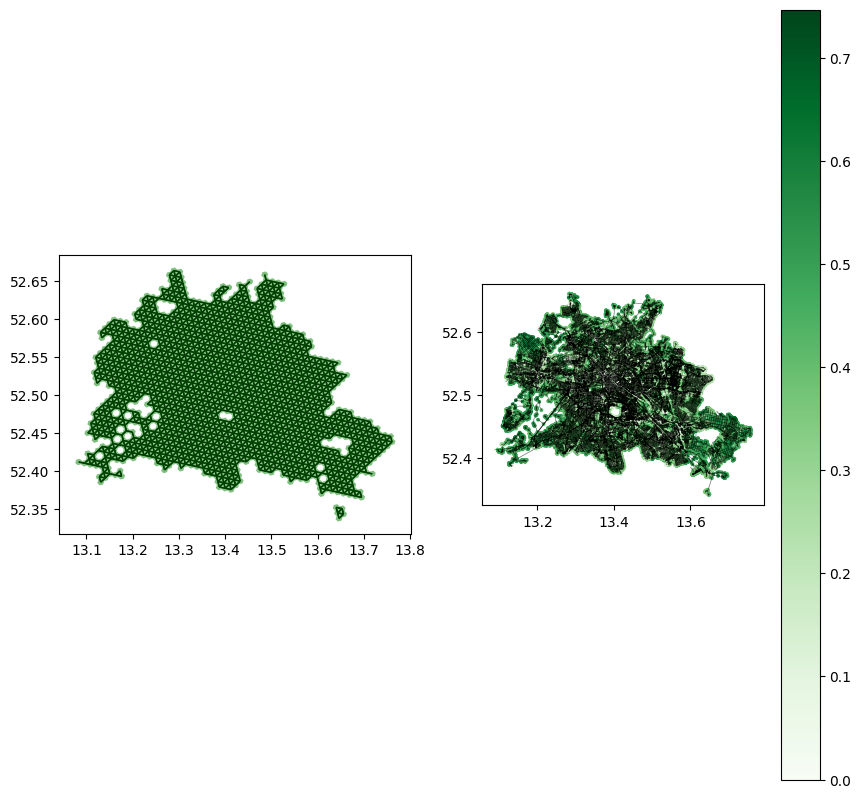

In [17]:
berlin_edges = gpd.read_file('data/berlin_edges.geojson')
berlin_nodes = gpd.read_file('data/berlin_nodes.geojson')   
berlin_nodes.drop(columns=['node_id','Green View Stdev','Sky View Stdev','Building View Stdev','Road View Stdev', 'Visual Complexity Mean','Visual Complexity Stdev'  ], inplace=True)
berlin_nodes.fillna(0, inplace=True)
h3_nodes_berlin, h3_edges_berlin = create_h3_aggregated_graph(berlin_nodes, agg_amst, h3_resolution=8)
f, ax = plt.subplots(1, 2, figsize=(10, 10))
h3_edges_berlin.plot(ax=ax[0], color='black', linewidth=1, zorder=1)
h3_nodes_berlin.plot(ax=ax[0], color='green', markersize=1, zorder=2, alpha=0.5)
berlin_nodes.plot(ax=ax[1], column='Green View Mean', cmap='Greens', legend=True, markersize=3)
berlin_edges.plot(ax=ax[1], color='black', linewidth=0.5, alpha=0.3)
#save nodes and edges to geojson
h3_nodes_berlin.fillna(0, inplace=True)
h3_edges_berlin.to_file('data/h3_edges_berlin.geojson', driver='GeoJSON')
h3_nodes_berlin.to_file('data/h3_nodes_berlin.geojson', driver='GeoJSON')

In [6]:
# load the h3 edges and nodes
h3_edges_berlin = gpd.read_file('data/h3_edges_berlin.geojson')
h3_nodes_berlin = gpd.read_file('data/h3_nodes_berlin.geojson')
h3_nodes_berlin.index = h3_nodes_berlin['h3_08']
h3_nodes_berlin.drop(columns=['h3_08'], inplace=True)
h3_nodes_berlin['Green View'] = h3_nodes_berlin['Green View Mean']

Skipping field osmid: unsupported OGR type: 13


/Users/stefanocarotti/FBK/GDS/Urbanity/utils.py:607: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  h3_nodes_amst['x'] = h3_nodes_amst.geometry.centroid.x
/Users/stefanocarotti/FBK/GDS/Urbanity/utils.py:608: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  h3_nodes_amst['y'] = h3_nodes_amst.geometry.centroid.y


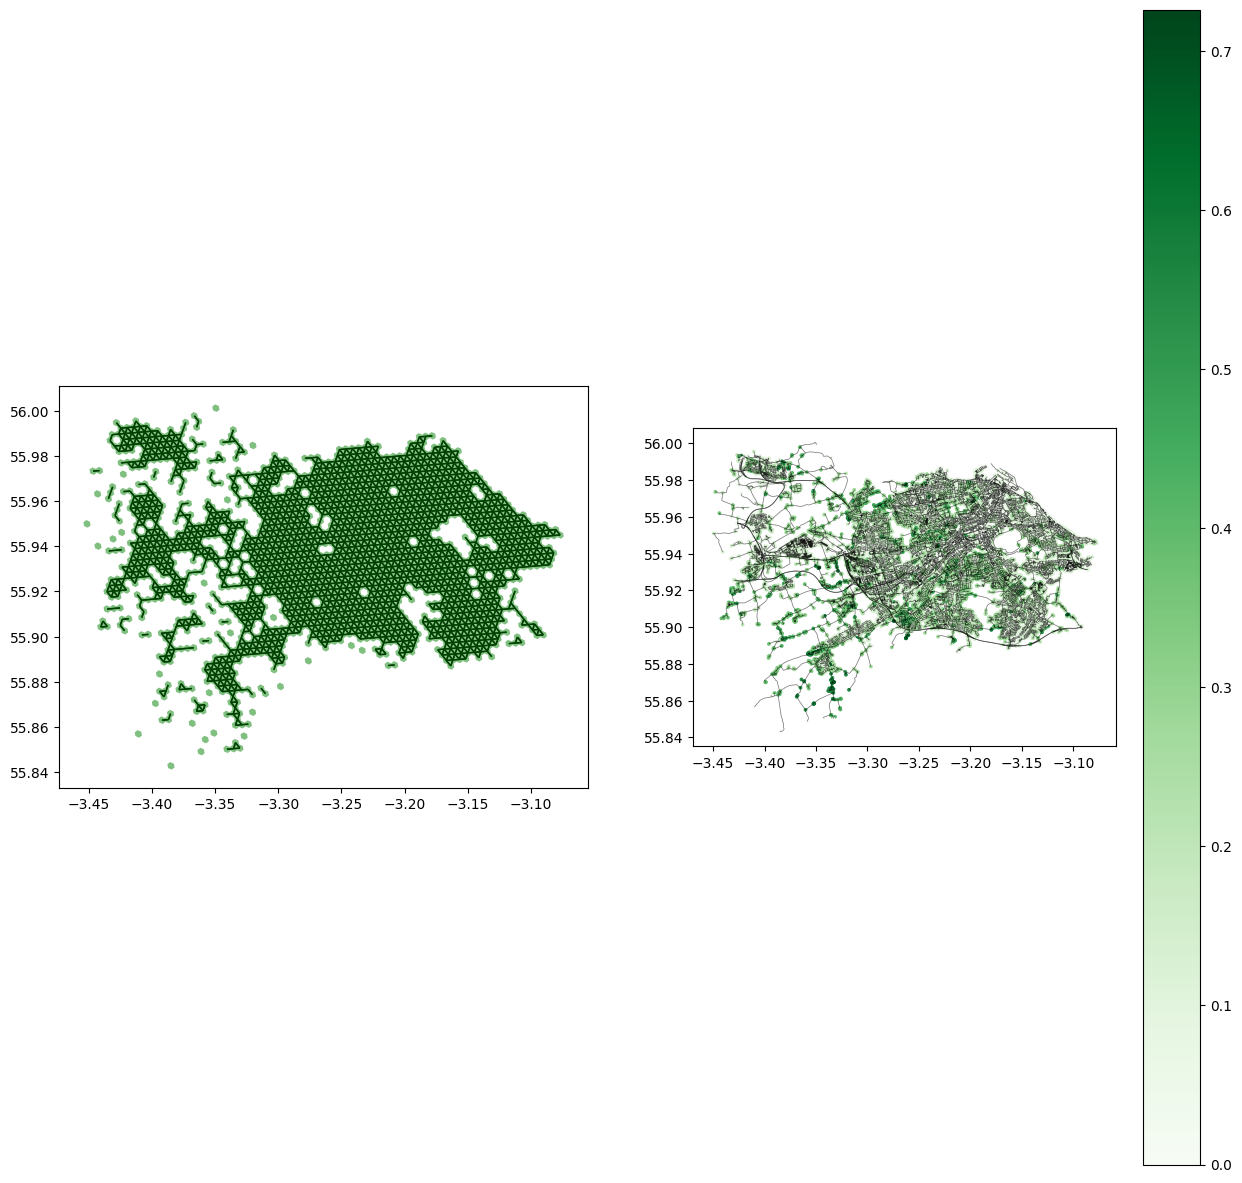

In [54]:
edinburgh_edges = gpd.read_file('data/edinburgh_edges.geojson')
edinburgh_nodes = gpd.read_file('data/edinburgh_nodes.geojson')
edinburgh_nodes.drop(columns=['node_id','Green View Stdev','Sky View Stdev','Building View Stdev','Road View Stdev', 'Visual Complexity Mean','Visual Complexity Stdev'  ], inplace=True)
edinburgh_nodes.fillna(0, inplace=True)
h3_nodes_edinburgh, h3_edges_edinburgh = create_h3_aggregated_graph(edinburgh_nodes, agg_amst, h3_resolution=9)
f, ax = plt.subplots(1, 2, figsize=(15, 15))
h3_edges_edinburgh.plot(ax=ax[0], color='black', linewidth=1, zorder=1)
h3_nodes_edinburgh.plot(ax=ax[0], color='green', markersize=1, zorder=2, alpha=0.5)
edinburgh_nodes.plot(ax=ax[1], column='Green View Mean', cmap='Greens', legend=True, markersize=3)
edinburgh_edges.plot(ax=ax[1], color='black', linewidth=0.5, alpha=0.3)
#save nodes and edges to geojson
h3_nodes_edinburgh.fillna(0, inplace=True)
h3_edges_edinburgh.to_file('data/h3_edges_edinburgh.geojson', driver='GeoJSON')
h3_nodes_edinburgh.to_file('data/h3_nodes_edinburgh.geojson', driver='GeoJSON') 

In [7]:
# load the h3 edges and nodes
h3_edges_edinburgh = gpd.read_file('data/h3_edges_edinburgh.geojson')
h3_nodes_edinburgh = gpd.read_file('data/h3_nodes_edinburgh.geojson')
h3_nodes_edinburgh.index = h3_nodes_edinburgh['h3_09']
h3_nodes_edinburgh.drop(columns=['h3_09'], inplace=True)
h3_nodes_edinburgh['Green View'] = h3_nodes_edinburgh['Green View Mean']

Skipping field osmid: unsupported OGR type: 13


# Model testing

In [67]:
# Initialize the model
model_basic = HybridModel_variant(
    in_channels=BasicData.num_features,
    pe_input_dim=BasicData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=2,
    head_channels=32,
    num_transformer_layers=4,
    num_gat_layers=4,
    dropout=0.4,
    combine_method='sum'
)
model_basic.to(device)
assert model_basic(BasicData.x, BasicData.pe, BasicData.edge_index).squeeze().shape == BasicData.y.shape, "Model output shape does not match target shape"

NameError: name 'BasicData' is not defined

In [ ]:

LR = 0.001
EPOCHS = 1000
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_basic.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
redraw_freq = 30

# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_performer(model_basic, BasicData, optimizer, criterion, epoch)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(model_basic, BasicData, BasicData.val_mask, criterion)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model_basic.state_dict(), 'bestmodels/best_hybrid_variant_model_amst.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
    
    # Print progress
    if epoch % 10 == 0:
        test_loss = evaluate(model_basic, BasicData, BasicData.test_mask, criterion)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, Counter: {early_stop_counter}')
    
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Final Test Results - Loss: 0.0028


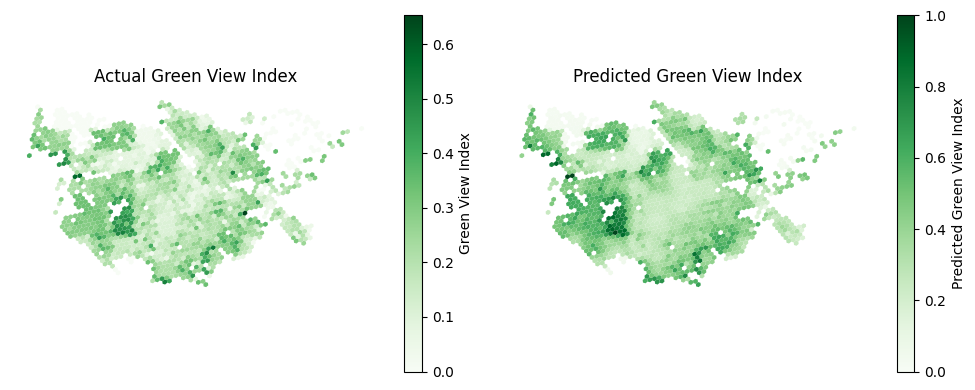

torch.Size([1614, 1614])


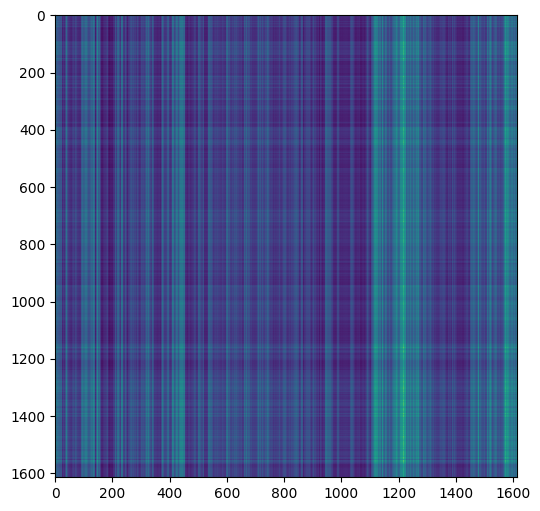

In [21]:
criterion = nn.MSELoss()
h3_nodes_amst['Green View'] = h3_nodes_amst['Green View Mean']
evaluate_and_visualize_predictions(model_basic, BasicData, 'bestmodels/best_hybrid_variant_model_amst.pth', h3_nodes_amst, criterion)
A_flow = make_attention_graph(model_basic, BasicData, model_type= 'Performer' ,fuse="aware")
print(A_flow.shape)
f, ax1 = plt.subplots(1, 1, figsize=(6, 6))
ax1.imshow(A_flow, cmap='viridis', )

Final Test Results - Loss: 0.0266


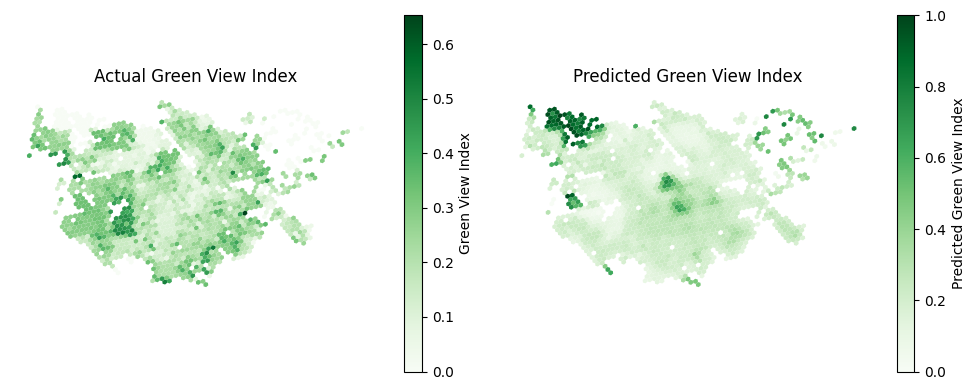

In [22]:
# Let's try a previous model trained on Paris without finetuning
model_paris = HybridModel_variant(
    in_channels=BasicData.num_features,
    pe_input_dim=BasicData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=2,
    head_channels=32,
    num_transformer_layers=4,
    num_gat_layers=4,
    dropout=0.4,
    combine_method='sum'
)
model_paris.to(device)
evaluate_and_visualize_predictions(model_paris, BasicData, 'best_models_paris/best_hybrid_variant_skyview.pth', h3_nodes_amst, criterion)

<Axes: >

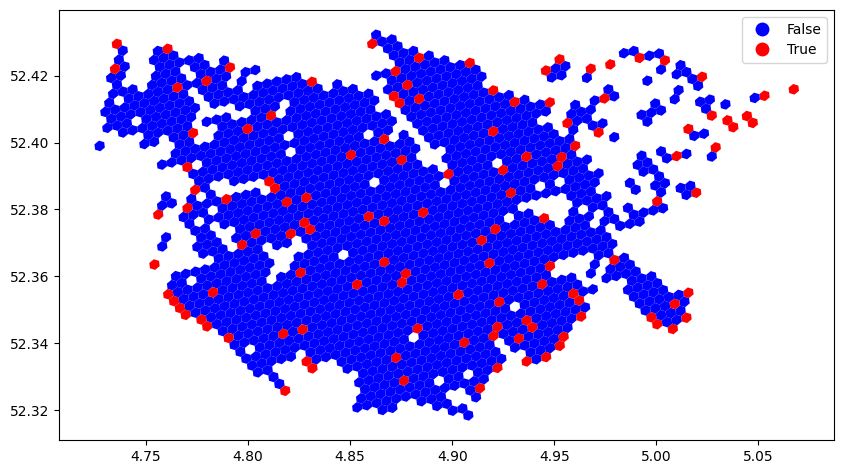

In [49]:
# let's add a very little fine-tuning to the model trained on Paris
finetune_mask = create_spatial_finetune_mask(h3_nodes_amst, BasicData.edge_index, 0.1, 'node')
h3_nodes_amst['Mask'] = finetune_mask
f, ax = plt.subplots(1, 1, figsize=(10, 10))
h3_nodes_amst.plot(ax=ax, column='Mask', cmap='bwr', legend=True, markersize=5)

In [50]:
def finetune(model, data, ft_mask):
    model.train()
    optimizer.zero_grad()
    
    # Forward pass on full graph
    out = model(data.x, data.pe, data.edge_index)
    predictions = out.squeeze(-1)
    
    # Loss only on masked edges
    loss = criterion(predictions[ft_mask], data.y[ft_mask])
    loss.backward()
    optimizer.step()
    
    return loss.item()

FT Epoch 5: Train Loss: 0.0098, Val Loss: 0.0091
FT Epoch 10: Train Loss: 0.0126, Val Loss: 0.0089
FT Epoch 15: Train Loss: 0.0107, Val Loss: 0.0086
FT Epoch 20: Train Loss: 0.0109, Val Loss: 0.0085
FT Epoch 25: Train Loss: 0.0100, Val Loss: 0.0085
FT Epoch 30: Train Loss: 0.0090, Val Loss: 0.0083
FT Epoch 35: Train Loss: 0.0098, Val Loss: 0.0080
FT Epoch 40: Train Loss: 0.0113, Val Loss: 0.0079
FT Epoch 45: Train Loss: 0.0108, Val Loss: 0.0079
FT Epoch 50: Train Loss: 0.0087, Val Loss: 0.0077
FT Epoch 55: Train Loss: 0.0089, Val Loss: 0.0075
FT Epoch 60: Train Loss: 0.0097, Val Loss: 0.0074
FT Epoch 65: Train Loss: 0.0073, Val Loss: 0.0073
FT Epoch 70: Train Loss: 0.0073, Val Loss: 0.0073
FT Epoch 75: Train Loss: 0.0082, Val Loss: 0.0074
FT Epoch 80: Train Loss: 0.0082, Val Loss: 0.0072
FT Epoch 85: Train Loss: 0.0081, Val Loss: 0.0070
FT Epoch 90: Train Loss: 0.0064, Val Loss: 0.0070
FT Epoch 95: Train Loss: 0.0086, Val Loss: 0.0068
FT Epoch 100: Train Loss: 0.0074, Val Loss: 0.0066


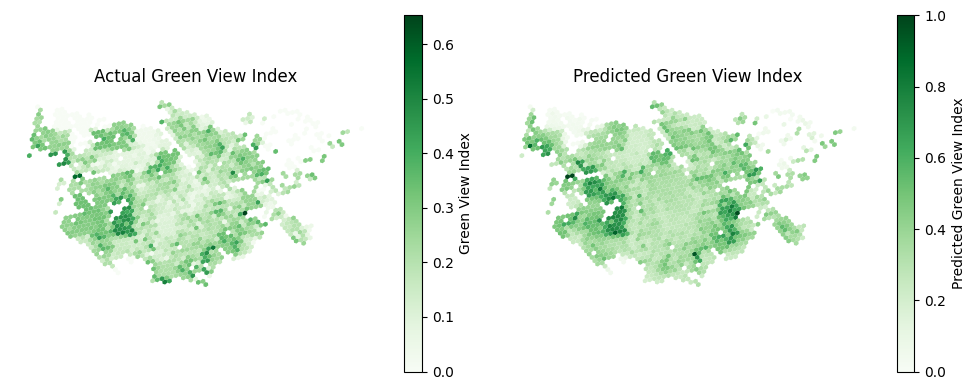

In [52]:
# Fine-tuning loop
LR = 0.0001
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_paris.parameters(), lr=LR)
FT_EPOCHS = 300
best_val_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 30  # Reduced from 100
ft_train_losses, ft_val_losses = [], []


for epoch in range(1, FT_EPOCHS + 1):
    # Training on fine-tuning mask
    ft_loss = finetune(model_paris, BasicData, finetune_mask)
    # Validation on original validation set
    val_loss = evaluate(model_paris, BasicData, BasicData.val_mask, criterion)
    
    # Scheduler and early stopping logic    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_paris.state_dict(), 'bestmodels/best_hybrid_variant_finetuned.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 5 == 0: 
        print(f"FT Epoch {epoch}: Train Loss: {ft_loss:.4f}, Val Loss: {val_loss:.4f}")
evaluate_and_visualize_predictions(model_paris, BasicData, '', h3_nodes_amst, criterion, branch='both')

This is actually looking pretty good, given I only showed it the 10% of the nodes of amsterdam

Now I will try to train on multiple cities.

In [23]:
h3_nodes['Green View Mean'] = h3_nodes['Green View']
h3_nodes['Sky View Mean'] = h3_nodes['Sky View']

In [24]:
device = 'cpu'
city_list = ['paris', 'amsterdam', 'milan', 'barcelona', 'edinburgh']
X_list = ['x', 'y', 'PopSum', 'POI','Sky View Mean']
processed_data_h3 = {}
for city in city_list:
    if city == 'paris':
        data = preprocess_data(h3_nodes, h3_edges, X_list= X_list, target='Green View')
    elif city == 'amsterdam':
        data = preprocess_data(h3_nodes_amst, h3_edges_amst, X_list= X_list, target='Green View Mean')
    elif city == 'milan':
        data = preprocess_data(h3_nodes_milan, h3_edges_milan,  X_list= X_list, target='Green View Mean')
    elif city == 'barcelona':
        data = preprocess_data(h3_nodes_barcelona, h3_edges_barcelona,  X_list= X_list, target='Green View Mean')
    
    processed_data_h3[city] = data.to(device)


In [69]:
processed_data = {}
for city in city_list:
    if city == 'paris':
        data = preprocess_data(paris_nodes, paris_edges, X_list=['x', 'y', 'PopSum', 'Sky View'], target='Green View', map_type= 'geo')
    elif city == 'amsterdam':
        data = preprocess_data(amsterdam_nodes, amsterdam_edges, X_list=['x', 'y', 'PopSum', 'Sky View Mean'], target='Green View Mean', map_type='geo')
    elif city == 'milan':
        data = preprocess_data(milan_nodes, milan_edges, X_list=['x', 'y', 'PopSum', 'Sky View Mean'], target='Green View Mean', map_type='geo')
    
    processed_data[city] = data.to(device)

In [25]:
data_list_h3 = list(processed_data_h3.values())
loader_h3 = DataLoader(data_list_h3, batch_size=1, shuffle=True)
for batch in loader_h3:
    print(f"Batch with {batch.num_nodes} nodes and {batch.num_edges} edges")


Batch with 1605 nodes and 8670 edges
Batch with 1228 nodes and 6844 edges
Batch with 987 nodes and 5396 edges
Batch with 1614 nodes and 8300 edges
Batch with 987 nodes and 5396 edges


In [11]:

data_list = list(processed_data.values())
loader = DataLoader(data_list, batch_size=1, shuffle=True)
for batch in loader:
    print(f"Batch with {batch.num_nodes} nodes and {batch.num_edges} edges")


NameError: name 'processed_data' is not defined

In [36]:
model = HybridModel_variant(
    in_channels=processed_data_h3['paris'].num_features,
    pe_input_dim=processed_data_h3['paris'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=2,
    head_channels=32,
    num_transformer_layers=4,
    num_gat_layers=4,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)
criterion = nn.MSELoss()
assert model(processed_data_h3['paris'].x, processed_data_h3['paris'].pe, processed_data_h3['paris'].edge_index).squeeze().shape == processed_data_h3['paris'].y.shape, "Model output shape does not match target shape"

In [37]:
model, trainloss, valloss = train_batched_model(model, loader_h3, 1000, 0.001, 'cpu', 'bestmodels/best_hybrid_variant_multicity_h3.pth', 100)

Starting training on cpu...
Epoch: 010, Train Loss: 0.0175, Val Loss: 0.0111, Test Loss: 0.0112, Counter: 4
Epoch: 020, Train Loss: 0.0141, Val Loss: 0.0088, Test Loss: 0.0088, Counter: 4
Epoch: 030, Train Loss: 0.0130, Val Loss: 0.0088, Test Loss: 0.0086, Counter: 3
Epoch: 040, Train Loss: 0.0118, Val Loss: 0.0081, Test Loss: 0.0079, Counter: 3
Epoch: 050, Train Loss: 0.0111, Val Loss: 0.0077, Test Loss: 0.0075, Counter: 2
Epoch: 060, Train Loss: 0.0103, Val Loss: 0.0079, Test Loss: 0.0076, Counter: 4
Epoch: 070, Train Loss: 0.0098, Val Loss: 0.0076, Test Loss: 0.0075, Counter: 2
Epoch: 080, Train Loss: 0.0093, Val Loss: 0.0068, Test Loss: 0.0069, Counter: 0
Epoch: 090, Train Loss: 0.0083, Val Loss: 0.0067, Test Loss: 0.0069, Counter: 3
Epoch: 100, Train Loss: 0.0079, Val Loss: 0.0067, Test Loss: 0.0068, Counter: 3
Epoch: 110, Train Loss: 0.0073, Val Loss: 0.0067, Test Loss: 0.0067, Counter: 6
Epoch: 120, Train Loss: 0.0072, Val Loss: 0.0079, Test Loss: 0.0078, Counter: 1
Epoch: 130, 

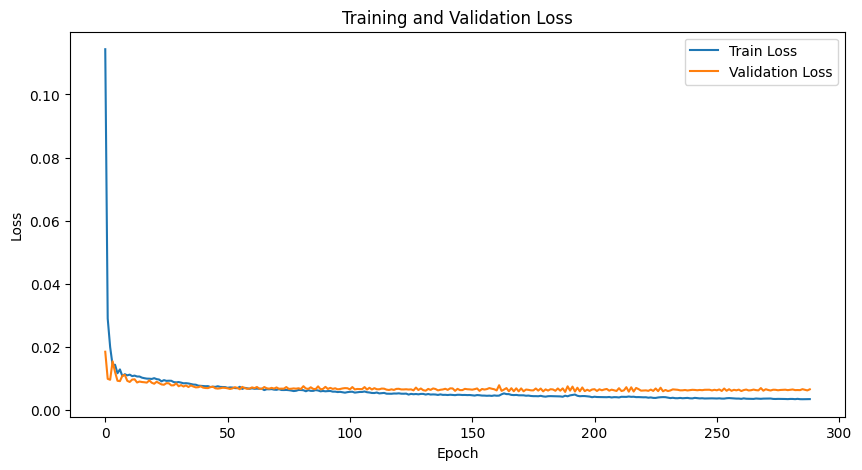

In [28]:
f, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(trainloss, label='Train Loss')
ax.plot(valloss, label='Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss')
ax.legend()
plt.show()

Final Test Results - Loss: 0.0051
Final Test Results - Loss: 0.0052
Final Test Results - Loss: 0.0050
Final Test Results - Loss: 0.0067


''

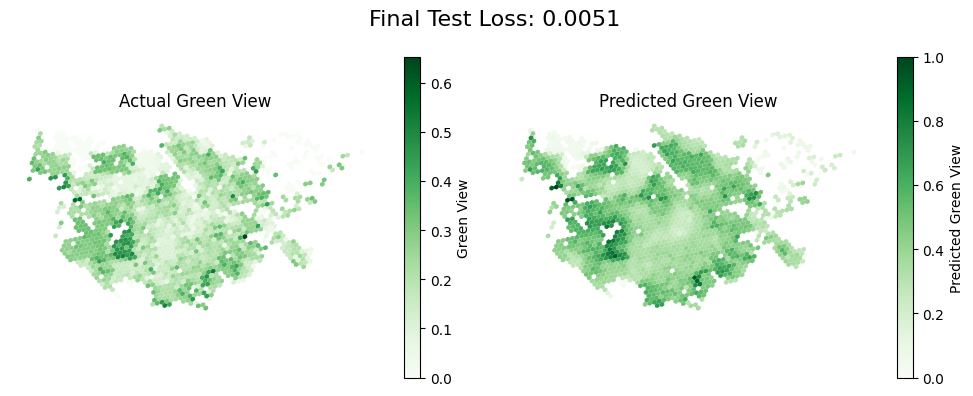

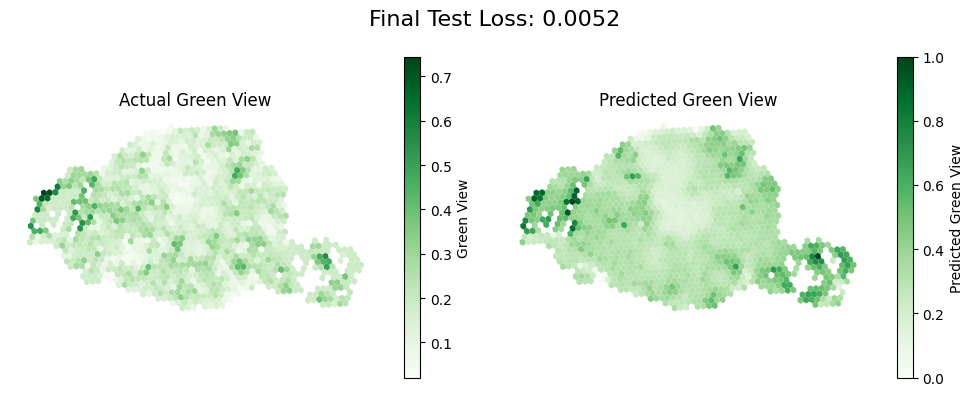

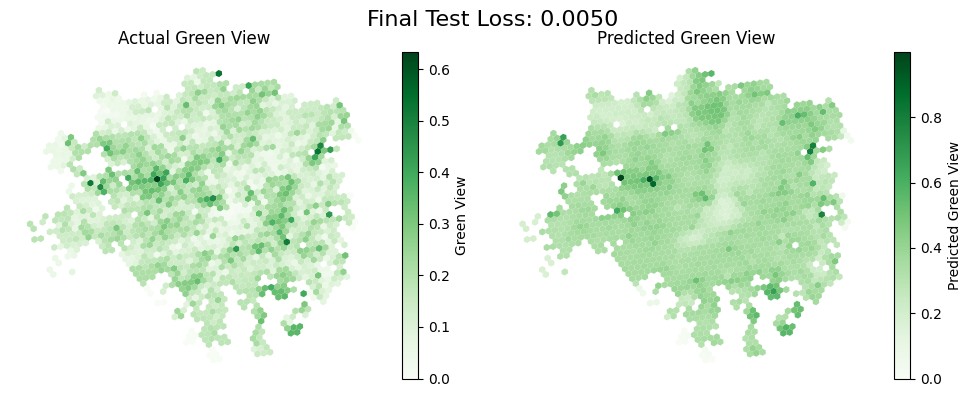

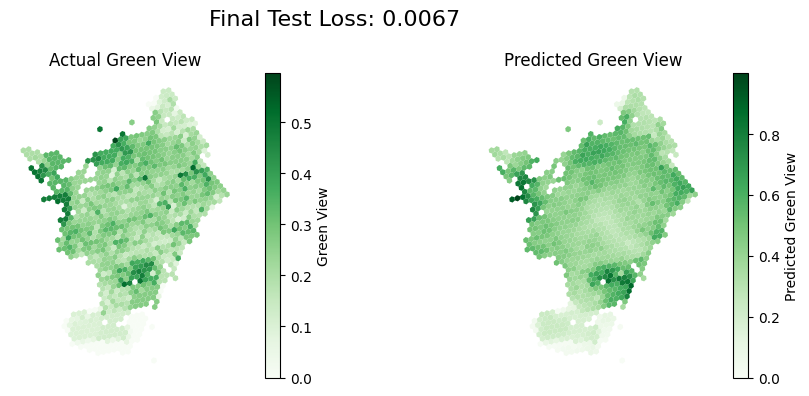

In [31]:
evaluate_and_visualize_predictions(model, processed_data_h3['amsterdam'], 'bestmodels/best_hybrid_variant_multicity_h3.pth', h3_nodes_amst, criterion)
evaluate_and_visualize_predictions(model, processed_data_h3['paris'], 'bestmodels/best_hybrid_variant_multicity_h3.pth', h3_nodes, criterion)
evaluate_and_visualize_predictions(model, processed_data_h3['milan'], 'bestmodels/best_hybrid_variant_multicity_h3.pth', h3_nodes_milan, criterion)
evaluate_and_visualize_predictions(model, processed_data_h3['barcelona'], 'bestmodels/best_hybrid_variant_multicity_h3.pth', h3_nodes_barcelona, criterion)
''

Final Test Results - Loss: 0.0308


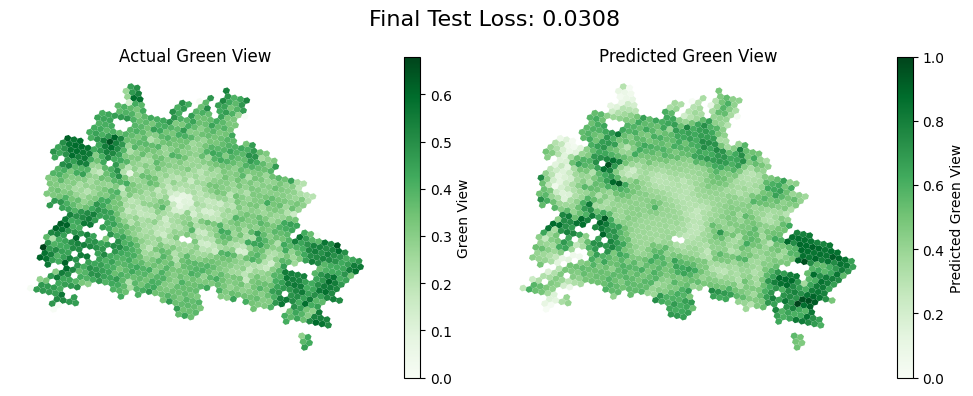

In [33]:
data_berlin = preprocess_data(h3_nodes_berlin, h3_edges_berlin, X_list=['x', 'y', 'PopSum', 'POI' ,'Sky View Mean'], target='Green View Mean')
f = evaluate_and_visualize_predictions(model, data_berlin, 'bestmodels/best_hybrid_variant_multicity_h3.pth', h3_nodes_berlin, criterion)


<Axes: >

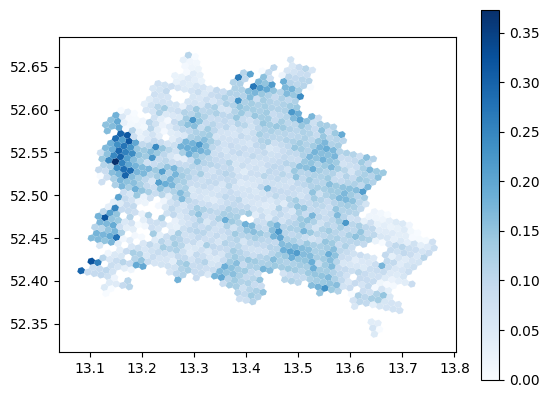

In [50]:
h3_nodes_berlin.plot(column='Sky View Mean', cmap='Blues', markersize=5, legend=True)

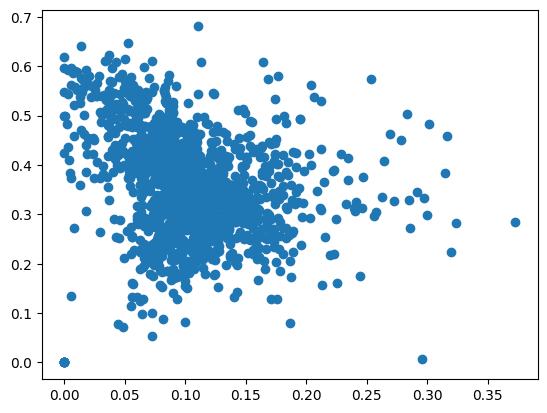

In [17]:
plt.scatter(h3_nodes_berlin['Sky View Mean'], h3_nodes_berlin['Green View Mean'])

In [18]:
import scipy
scipy.stats.pearsonr(h3_nodes_berlin['Sky View Mean'], h3_nodes_berlin['Green View Mean'])

PearsonRResult(statistic=-0.26148615616417714, pvalue=2.7424894663253016e-23)

In [49]:
model2 = HybridModel_variant(
    in_channels=processed_data_h3['paris'].num_features,
    pe_input_dim=processed_data_h3['paris'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=2,
    head_channels=32,
    num_transformer_layers=4,
    num_gat_layers=4,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)
assert model(processed_data_h3['paris'].x, processed_data_h3['paris'].pe, processed_data_h3['paris'].edge_index).squeeze().shape == processed_data_h3['paris'].y.shape, "Model output shape does not match target shape"

In [ ]:
LR = 0.001
EPOCHS = 1000
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
early_stop_patience = 100
best_loss = float('inf')
early_stop_counter = 0
train_losses, val_losses = [], []

print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    model2.train()
    epoch_train_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        batch = batch.to(device)
        out = model2(batch.x, batch.pe, batch.edge_index)
        loss = criterion(out.squeeze(), batch.y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    epoch_train_loss /= len(loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model2.eval()
    with torch.no_grad():
        val_loss = 0
        for batch in loader:
            batch = batch.to(device)
            out = model2(batch.x, batch.pe, batch.edge_index)
            loss = criterion(out.squeeze(), batch.y)
            val_loss += loss.item()
        val_loss /= len(loader)
        val_losses.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model2.state_dict(), 'bestmodels/best_hybrid_variant_multicity.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {val_loss:.4f}, Counter: {early_stop_counter}')

    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 0.0157, Val Loss: 0.0111, Counter: 3
Epoch: 020, Train Loss: 0.0138, Val Loss: 0.0105, Counter: 1
Epoch: 030, Train Loss: 0.0139, Val Loss: 0.0097, Counter: 0
Epoch: 040, Train Loss: 0.0128, Val Loss: 0.0095, Counter: 0
Epoch: 050, Train Loss: 0.0121, Val Loss: 0.0096, Counter: 2
Epoch: 060, Train Loss: 0.0122, Val Loss: 0.0098, Counter: 1
Epoch: 070, Train Loss: 0.0116, Val Loss: 0.0092, Counter: 2
Epoch: 080, Train Loss: 0.0111, Val Loss: 0.0094, Counter: 2
Epoch: 090, Train Loss: 0.0111, Val Loss: 0.0089, Counter: 1
Epoch: 100, Train Loss: 0.0101, Val Loss: 0.0081, Counter: 0
Epoch: 110, Train Loss: 0.0097, Val Loss: 0.0079, Counter: 1
Epoch: 120, Train Loss: 0.0093, Val Loss: 0.0075, Counter: 0
Epoch: 130, Train Loss: 0.0090, Val Loss: 0.0074, Counter: 1
Epoch: 140, Train Loss: 0.0088, Val Loss: 0.0072, Counter: 0
Epoch: 150, Train Loss: 0.0084, Val Loss: 0.0069, Counter: 0
Epoch: 160, Train Loss: 0.0088, Val Loss: 0.0097, Counter

KeyboardInterrupt: 

Final Test Results - Loss: 0.0038


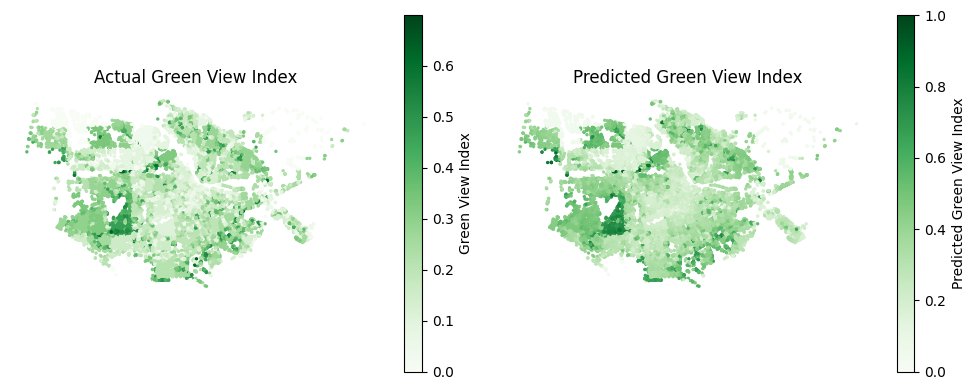

Final Test Results - Loss: 0.0036


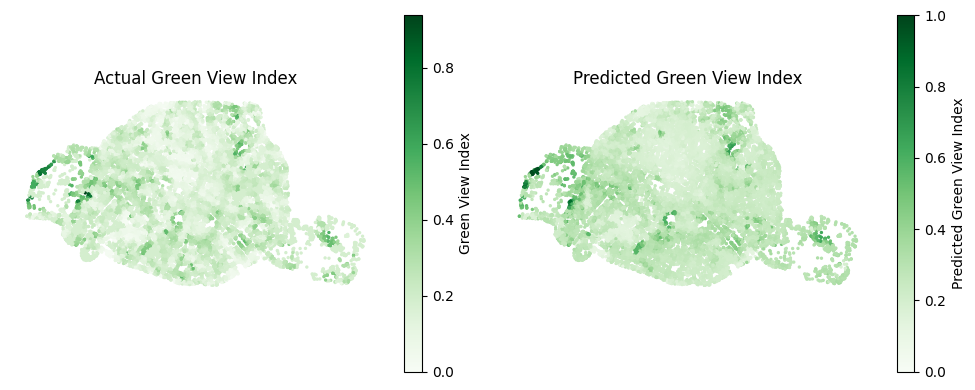

Final Test Results - Loss: 0.0054


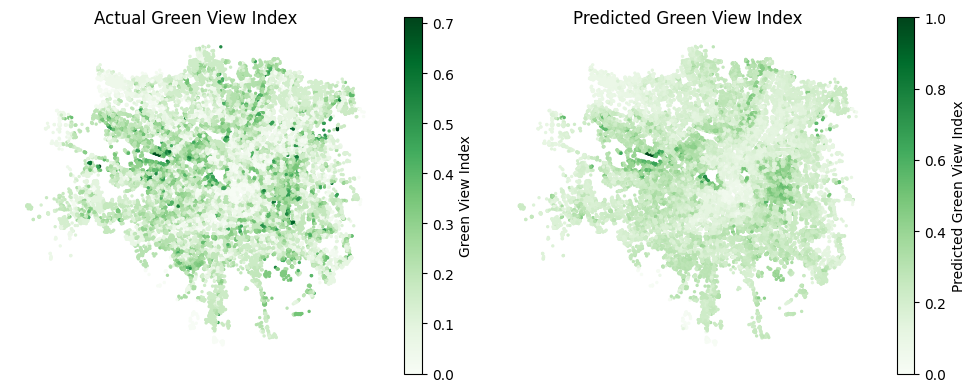

In [53]:
amsterdam_nodes['Green View'] = amsterdam_nodes['Green View Mean']
milan_nodes['Green View'] = milan_nodes['Green View Mean']
evaluate_and_visualize_predictions(model2, processed_data['amsterdam'], 'bestmodels/best_hybrid_variant_multicity.pth', amsterdam_nodes, criterion)
evaluate_and_visualize_predictions(model2, processed_data['paris'], 'bestmodels/best_hybrid_variant_multicity.pth', paris_nodes, criterion)
evaluate_and_visualize_predictions(model2, processed_data['milan'], 'bestmodels/best_hybrid_variant_multicity.pth', milan_nodes, criterion)

Final Test Results - Loss: 0.0157


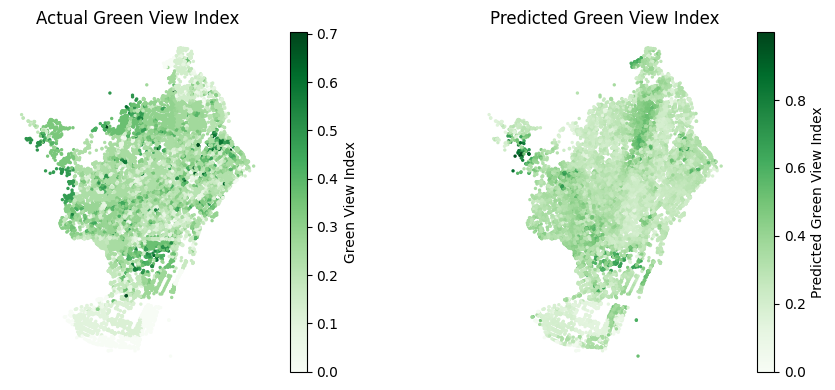

In [57]:
evaluate_and_visualize_predictions(model2, data_2, 'bestmodels/best_hybrid_variant_multicity.pth', barcelona_nodes, criterion)

Final Test Results - Loss: 0.0063


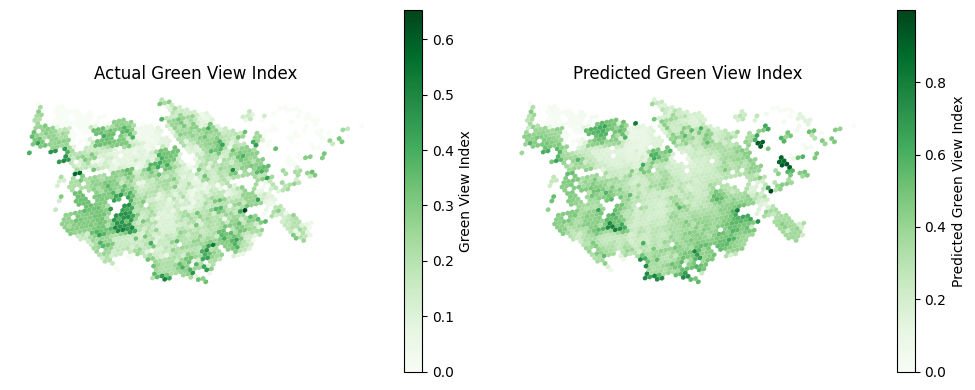

Final Test Results - Loss: 0.0038


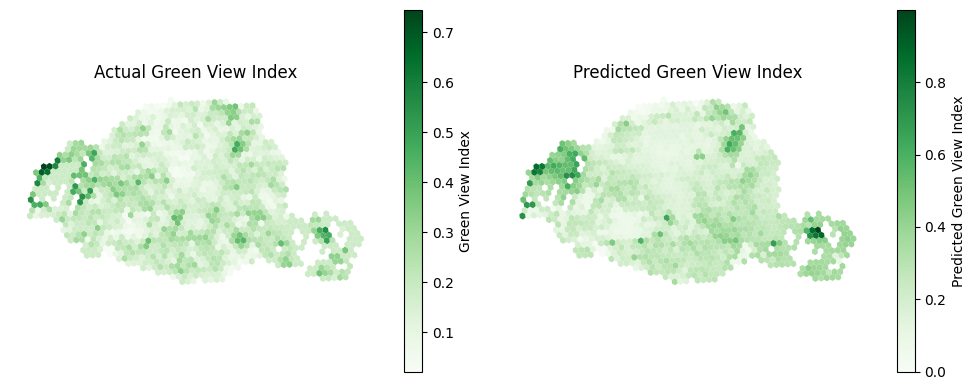

Final Test Results - Loss: 0.0057


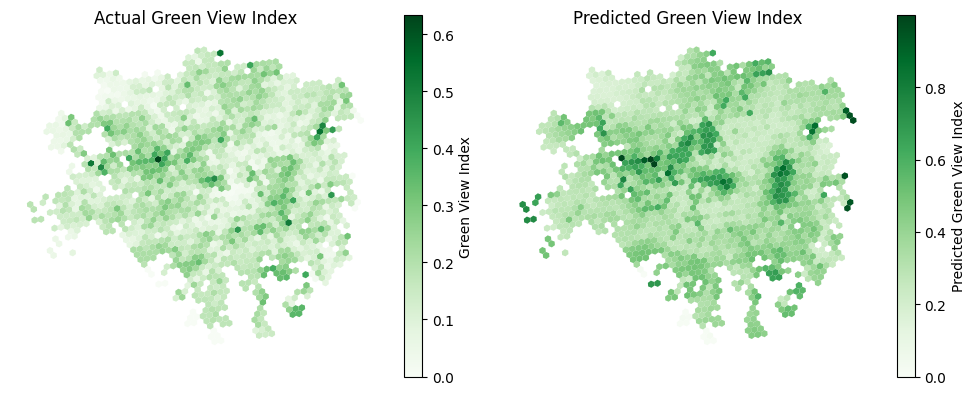

Final Test Results - Loss: 0.0172


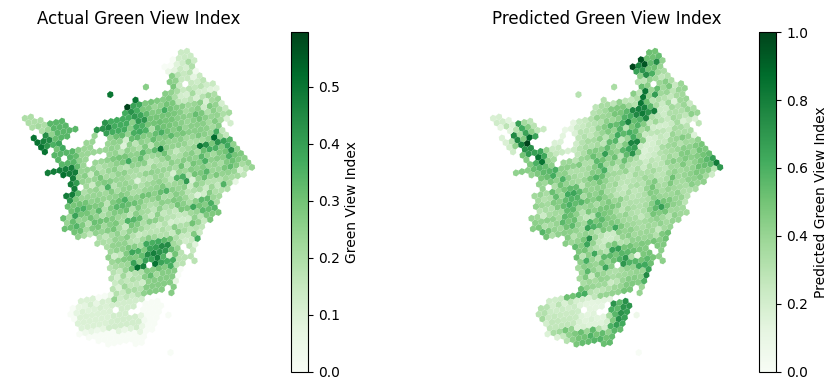

In [58]:
evaluate_and_visualize_predictions(model2, processed_data_h3['amsterdam'], 'bestmodels/best_hybrid_variant_multicity.pth', h3_nodes_amst, criterion)
evaluate_and_visualize_predictions(model2, processed_data_h3['paris'], 'bestmodels/best_hybrid_variant_multicity.pth', h3_nodes, criterion)
evaluate_and_visualize_predictions(model2, processed_data_h3['milan'], 'bestmodels/best_hybrid_variant_multicity.pth', h3_nodes_milan, criterion)
evaluate_and_visualize_predictions(model2, data, 'bestmodels/best_hybrid_variant_multicity.pth', h3_nodes_barcelona, criterion)